# Assay homogeneity
How similar are the compounds in a single assays.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from multiprocessing import Pool
import tqdm.auto as tqdm
from functools import namedtuple

import dti.data as dat
import dti.constants as const
from dti.utils import compute_fp

In [2]:
d = dat.load_kinodata("../data/raw/activities-chembl33_v0.5.csv")

In [3]:
def add_fp_col(d: pd.DataFrame):
    with Pool(6) as p:
        fps = p.map(compute_fp, tqdm.tqdm(d[const.SMILES].values))
    d["fp"] = fps
    d.dropna(subset=["fp"], inplace=True)
    assert not d["fp"].isna().any()

In [4]:
add_fp_col(d)

  0%|          | 0/179982 [00:00<?, ?it/s]

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X = np.stack(d["fp"].values)
from sklearn.feature_selection import VarianceThreshold

cluster_labels = d[const.ASSAY].values
X_train, X_test, y_train, y_test = train_test_split(X, cluster_labels)
selector = VarianceThreshold(threshold=0.05)  # you can adjust the threshold
X_train = selector.fit_transform(X_train)
X_test = selector.transform(X_test)

In [8]:
X_train.shape

(134986, 263)

In [ ]:
import lightgbm as lgb

clf = lgb.LGBMClassifier(n_jobs=4, force_col_wise=True)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

[LightGBM] [Info] Total Bins 526
[LightGBM] [Info] Number of data points in the train set: 134986, number of used features: 263
[LightGBM] [Info] Start training from score -10.021167
[LightGBM] [Info] Start training from score -11.812926
[LightGBM] [Info] Start training from score -11.812926
[LightGBM] [Info] Start training from score -11.812926
[LightGBM] [Info] Start training from score -9.104876
[LightGBM] [Info] Start training from score -11.812926
[LightGBM] [Info] Start training from score -10.426632
[LightGBM] [Info] Start training from score -8.817194
[LightGBM] [Info] Start training from score -11.812926
[LightGBM] [Info] Start training from score -10.426632
[LightGBM] [Info] Start training from score -8.817194
[LightGBM] [Info] Start training from score -8.922555
[LightGBM] [Info] Start training from score -11.812926
[LightGBM] [Info] Start training from score -10.203488
[LightGBM] [Info] Start training from score -9.510341
[LightGBM] [Info] Start training from score -8.86848

In [ ]:
accuracy

In [5]:
def assay_variability(d: pd.DataFrame) -> pd.DataFrame:
    if "fp" not in d.columns:
        add_fp_col(d)
    Row = namedtuple("Row", [const.ASSAY, "variability", "size"])
    rows = []
    for assay, g in tqdm.tqdm(d.groupby(const.ASSAY)):
        var = np.stack(g["fp"].values).var()
        rows.append(Row(assay, var, len(g)))

    return pd.DataFrame(rows)

In [6]:
df_var = assay_variability(d)

  0%|          | 0/54787 [00:00<?, ?it/s]

array([[<Axes: title={'center': 'variability'}>]], dtype=object)

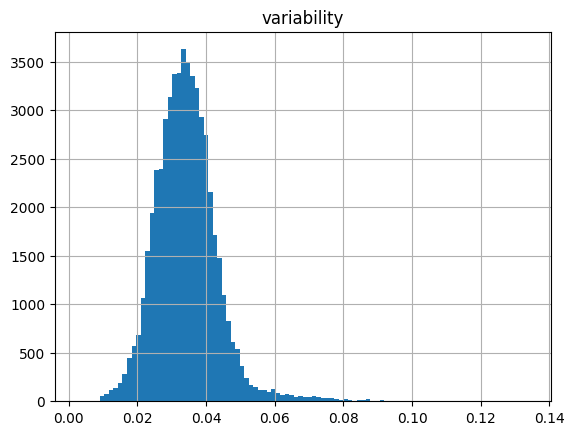

In [7]:
df_var[["variability"]].hist(bins=100)

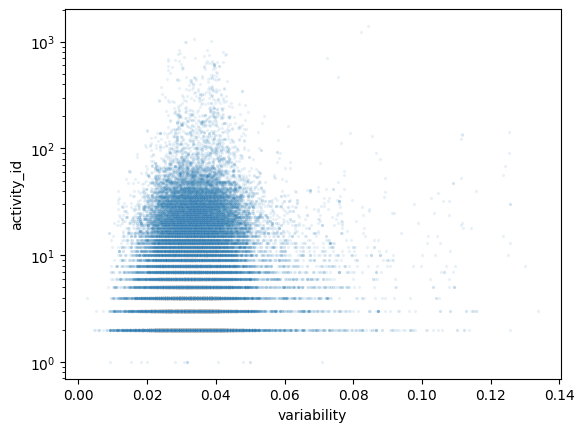

In [8]:
sns.scatterplot(
    d.groupby(const.ASSAY).count().join(df_var.set_index(const.ASSAY)),
    y="activity_id",
    x="variability",
    s=5,
    alpha=0.1,
)
plt.yscale("log")

In [9]:
df_var.set_index(const.ASSAY, inplace=True)

In [11]:
dp = pd.concat(
    [
        pd.read_csv(fname, index_col=0)
        for fname in [
            "../data/hpc-data/omnivore_0_sets_4e93/predictions.csv.gz",
            "../data/hpc-data/omnivore_1_sets_8ec5/predictions.csv.gz",
            "../data/hpc-data/omnivore_2_sets_47fb/predictions.csv.gz",
            "../data/hpc-data/omnivore_3_sets_4bbc/predictions.csv.gz",
            "../data/hpc-data/omnivore_4_sets_bb0e/predictions.csv.gz",
        ]
    ]
)

In [12]:
for assay, g in tqdm.tqdm(dp.groupby(const.ASSAY)):
    df_var.loc[assay, "corr"] = g[["prediction", "target"]].corr("pearson").values[1, 0]

  0%|          | 0/45453 [00:00<?, ?it/s]

In [13]:
df_var.dropna(subset=["corr"], inplace=True)

In [14]:
df_var["log_size"] = np.log(df_var["size"])

In [15]:
df_var["fisher_corr"] = np.atanh(df_var["corr"])

/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)


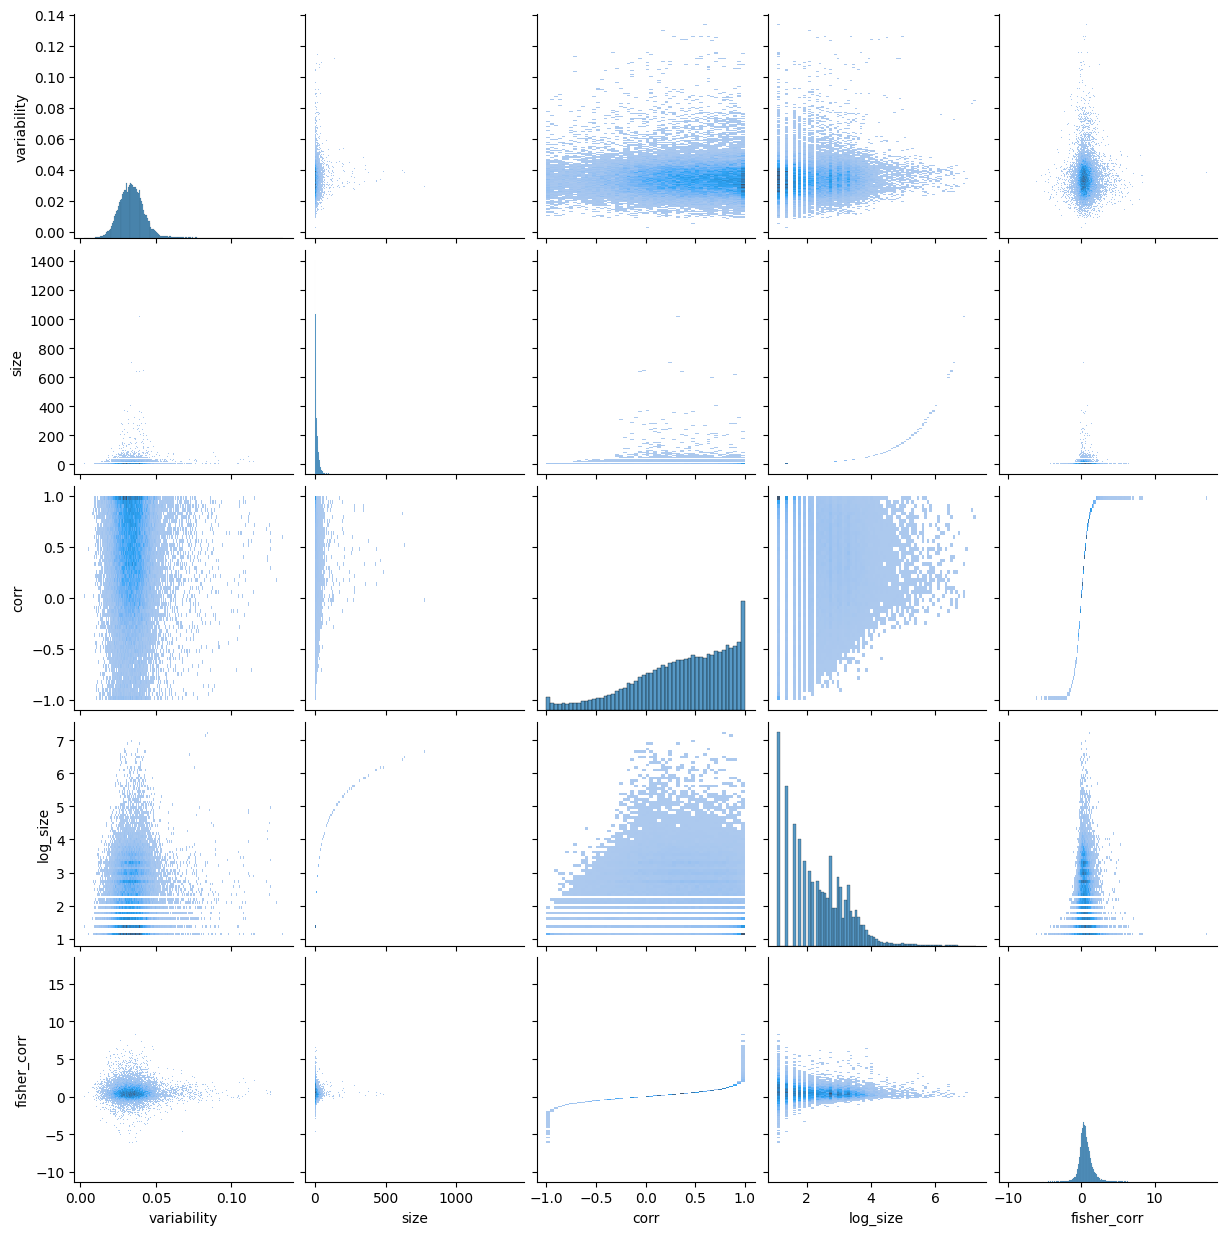

In [16]:
sns.pairplot(df_var, kind="hist")

In [17]:
df_var.corr("spearman")

,variability,size,corr,log_size,fisher_corr
variability,1.000000,0.067726,-0.014336,0.067726,-0.014312
size,0.067726,1.000000,-0.090739,1.000000,-0.090578
corr,-0.014336,-0.090739,1.000000,-0.090739,1.000000
log_size,0.067726,1.000000,-0.090739,1.000000,-0.090578
fisher_corr,-0.014312,-0.090578,1.000000,-0.090578,1.000000


<Axes: xlabel='fisher_corr', ylabel='Count'>

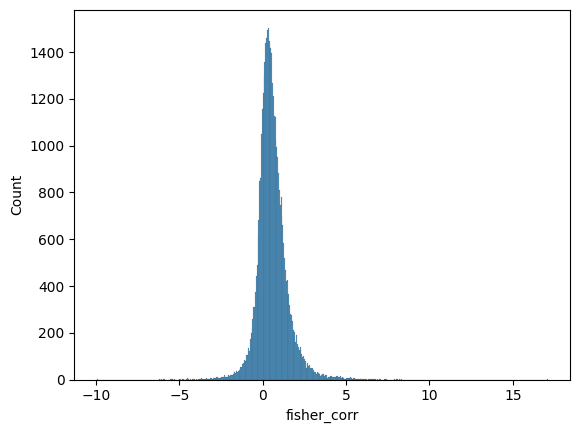

In [18]:
sns.histplot(df_var, x="fisher_corr", common_norm=True)

<Axes: xlabel='corr', ylabel='Count'>

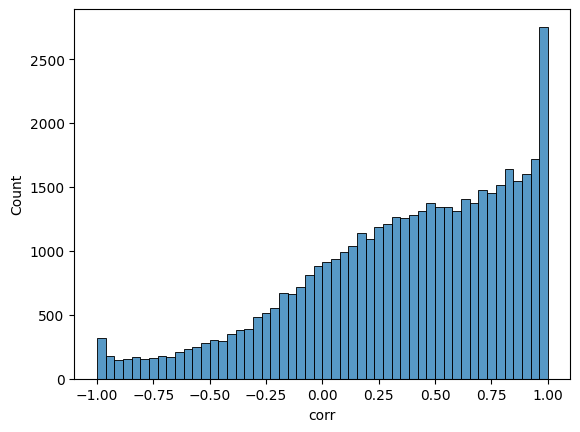

In [19]:
sns.histplot(df_var, x="corr", common_norm=True)

In [20]:
(df_var["corr"].abs() == 1).mean()

np.float64(2.2173440652786093e-05)

<Axes: xlabel='size', ylabel='Probability'>

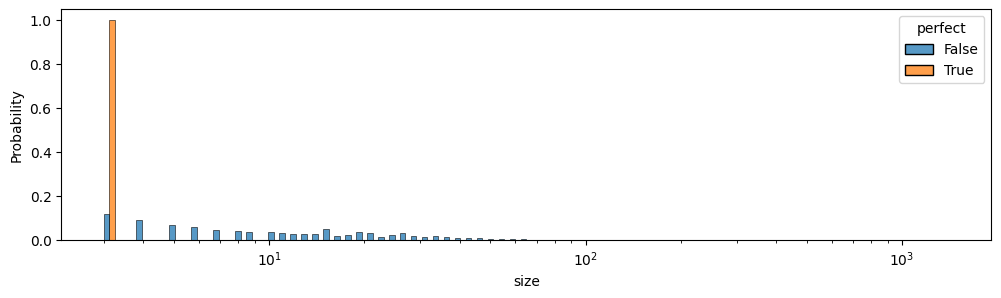

In [21]:
df_var["perfect"] = df_var["corr"] == 1
plt.figure(figsize=(12, 3))
sns.histplot(
    df_var,
    x="size",
    hue="perfect",
    multiple="dodge",
    stat="probability",
    common_norm=False,
    log_scale=True,
)